In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

Data Gathering 

In [10]:
df = pd.read_csv(r'C:\Users\RITIK\OneDrive\New folder\python\International_Education_Costs.csv')

In [12]:
df.head(5)

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
0,USA,Cambridge,Harvard University,Computer Science,Master,2.0,55400,83.5,2200,160,1500,1.00
1,UK,London,Imperial College London,Data Science,Master,1.0,41200,75.8,1800,485,800,0.79
2,Canada,Toronto,University of Toronto,Business Analytics,Master,2.0,38500,72.5,1600,235,900,1.35
3,Australia,Melbourne,University of Melbourne,Engineering,Master,2.0,42000,71.2,1400,450,650,1.52
4,Germany,Munich,Technical University of Munich,Mechanical Engineering,Master,2.0,500,70.5,1100,75,550,0.92


Data Exploration , Cleaning and Pre-processing

In [13]:
df.tail(5)


,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
902,France,Strasbourg,University of Strasbourg,Data Analytics,Master,2.0,4000,70.2,1000,99,850,0.92
903,Malaysia,Nilai,USIM,Computer Science,Bachelor,3.0,6800,50.5,400,120,400,4.65
904,Saudi Arabia,Al-Ahsa,King Faisal University,Information Systems,Master,2.0,4200,64.2,600,200,800,3.75
905,USA,Seattle,University of Washington,Software Development,PhD,5.0,50000,77.8,2000,160,1500,1.00
906,UK,Nottingham,University of Nottingham,Data Engineering,Master,2.0,34000,61.2,800,485,800,0.79


In [17]:
df.sample(5)

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
259,UK,Surrey,University of Surrey,Computer Science,Bachelor,3.0,25900,71.8,1150,490,800,0.79
890,Saudi Arabia,Tabuk,University of Tabuk,Computer Engineering,Bachelor,4.0,4100,63.2,580,200,800,3.75
3,Australia,Melbourne,University of Melbourne,Engineering,Master,2.0,42000,71.2,1400,450,650,1.52
67,Japan,Tsukuba,University of Tsukuba,Information Systems,Bachelor,4.0,7200,64.2,600,220,750,145.80
561,Portugal,Vila Real,UTAD,Computer Engineering,Master,2.0,5700,54.3,450,75,400,0.92


In [19]:
df.describe()

,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
count,907.000000,907.000000,907.000000,907.000000,907.000000,907.000000,907.000000
mean,2.836825,16705.016538,64.437486,969.206174,211.396913,700.077178,623.000695
std,0.945449,16582.385275,14.056333,517.154752,143.435740,320.374875,3801.746134
min,1.000000,0.000000,27.800000,150.000000,40.000000,200.000000,0.150000
25%,2.000000,2850.000000,56.300000,545.000000,100.000000,450.000000,0.920000
50%,3.000000,7500.000000,67.500000,900.000000,160.000000,650.000000,1.350000
75%,4.000000,31100.000000,72.200000,1300.000000,240.000000,800.000000,7.150000
max,5.000000,62000.000000,122.400000,2500.000000,490.000000,1500.000000,42150.000000


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 907 entries, 0 to 906
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country            907 non-null    object 
 1   City               907 non-null    object 
 2   University         907 non-null    object 
 3   Program            907 non-null    object 
 4   Level              907 non-null    object 
 5   Duration_Years     907 non-null    float64
 6   Tuition_USD        907 non-null    int64  
 7   Living_Cost_Index  907 non-null    float64
 8   Rent_USD           907 non-null    int64  
 9   Visa_Fee_USD       907 non-null    int64  
 10  Insurance_USD      907 non-null    int64  
 11  Exchange_Rate      907 non-null    float64
dtypes: float64(3), int64(4), object(5)
memory usage: 85.2+ KB


In [22]:
df.shape

(907, 12)

In [24]:
df.size

10884

In [25]:
df.dtypes

Country               object
City                  object
University            object
Program               object
Level                 object
Duration_Years       float64
Tuition_USD            int64
Living_Cost_Index    float64
Rent_USD               int64
Visa_Fee_USD           int64
Insurance_USD          int64
Exchange_Rate        float64
dtype: object

In [27]:
df['Country'].value_counts()

Country
UK                93
Australia         86
USA               78
Canada            76
Germany           33
                  ..
Nigeria            1
Israel             1
Taiwan             1
South Africa       1
Czech Republic     1
Name: count, Length: 71, dtype: int64

In [29]:
df['Country'].unique()

array(['USA', 'UK', 'Canada', 'Australia', 'Germany', 'Japan',
       'Netherlands', 'Singapore', 'France', 'Switzerland', 'Sweden',
       'Denmark', 'China', 'South Korea', 'Ireland', 'New Zealand',
       'Austria', 'Belgium', 'Hong Kong', 'Portugal', 'Israel', 'Taiwan',
       'Czech Republic', 'India', 'Poland', 'Malaysia', 'Spain', 'Italy',
       'Finland', 'Norway', 'Brazil', 'Turkey', 'Russia', 'Mexico',
       'Greece', 'Thailand', 'UAE', 'South Africa', 'Egypt', 'Argentina',
       'Indonesia', 'Saudi Arabia', 'Nigeria', 'Vietnam', 'Hungary',
       'Iceland', 'Colombia', 'Romania', 'Luxembourg', 'Tunisia',
       'Cyprus', 'Croatia', 'Dominican Republic', 'Morocco', 'Peru',
       'Ecuador', 'Lebanon', 'Bahrain', 'Uruguay', 'Bulgaria', 'Ghana',
       'Algeria', 'Panama', 'Bangladesh', 'Kuwait', 'Ukraine', 'Slovenia',
       'Serbia', 'Iran', 'Uzbekistan', 'El Salvador'], dtype=object)

In [30]:
df[df['Country']=='India']

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
44,India,Bangalore,Indian Institute of Science,Computer Science,Master,2.0,2500,45.6,500,200,300,83.20
648,India,Bangalore,Indian Institute of Science,Data Science,PhD,4.0,2000,45.2,300,180,300,82.75
654,India,Mumbai,IIT Bombay,Computer Engineering,Master,2.0,1800,47.5,350,180,300,82.75
659,India,Delhi,IIT Delhi,Artificial Intelligence,PhD,4.0,1900,44.8,320,180,300,82.75
665,India,Chennai,IIT Madras,Software Engineering,Master,2.0,1700,42.4,280,180,300,82.75
671,India,Hyderabad,IIT Hyderabad,Data Analytics,PhD,4.0,1800,41.2,260,180,300,82.75
677,India,Pune,IIT Pune,Computer Science,Master,2.0,1600,40.5,250,180,300,82.75
683,India,Kanpur,IIT Kanpur,Artificial Intelligence,PhD,4.0,1900,39.8,240,180,300,82.75


In [31]:
df['Country']=='India'

0      False
1      False
2      False
3      False
4      False
       ...  
902    False
903    False
904    False
905    False
906    False
Name: Country, Length: 907, dtype: bool

In [32]:
df.columns

Index(['Country', 'City', 'University', 'Program', 'Level', 'Duration_Years',
       'Tuition_USD', 'Living_Cost_Index', 'Rent_USD', 'Visa_Fee_USD',
       'Insurance_USD', 'Exchange_Rate'],
      dtype='object')

In [34]:
df['City'].value_counts()

City
Singapore     18
Melbourne     11
Sydney        11
London        10
Canberra       8
              ..
Porto          1
Uppsala        1
Wellington     1
Herning        1
Al-Ahsa        1
Name: count, Length: 556, dtype: int64

In [36]:
df['Program'].value_counts()

Program
Computer Science           312
Data Science                82
Computer Engineering        71
Software Engineering        57
Artificial Intelligence     53
                          ... 
Technology & Innovation      1
Computing & Innovation       1
Digital Systems & AI         1
Business Informatics         1
Data Systems                 1
Name: count, Length: 92, dtype: int64

In [37]:
df['Level'].value_counts()

Level
Master      451
Bachelor    297
PhD         159
Name: count, dtype: int64

In [38]:
df['Duration_Years'].max()

5.0

In [39]:
df['Duration_Years'].mean()

np.float64(2.8368246968026463)

In [40]:
df.isna()

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
902,False,False,False,False,False,False,False,False,False,False,False,False
903,False,False,False,False,False,False,False,False,False,False,False,False
904,False,False,False,False,False,False,False,False,False,False,False,False
905,False,False,False,False,False,False,False,False,False,False,False,False


In [42]:
df.isnull().sum()

Country              0
City                 0
University           0
Program              0
Level                0
Duration_Years       0
Tuition_USD          0
Living_Cost_Index    0
Rent_USD             0
Visa_Fee_USD         0
Insurance_USD        0
Exchange_Rate        0
dtype: int64

In [46]:
df.dtypes

Country               object
City                  object
University            object
Program               object
Level                 object
Duration_Years       float64
Tuition_USD            int64
Living_Cost_Index    float64
Rent_USD               int64
Visa_Fee_USD           int64
Insurance_USD          int64
Exchange_Rate        float64
dtype: object

In [44]:
df.duplicated().sum()

np.int64(0)

In [52]:
df['Duration_Years'] = df['Duration_Years'].astype('float32')

In [53]:
df['Living_Cost_Index'] = df['Living_Cost_Index'].astype('float32')

In [54]:
df['Exchange_Rate'] = df['Exchange_Rate'].astype('float32')

In [58]:
df['Tuition_USD'] = df['Tuition_USD'].astype('int32')

In [59]:
df['Rent_USD'] = df['Rent_USD'].astype('int32')

In [60]:
df['Insurance_USD'] = df['Insurance_USD'].astype('int32')

In [61]:
df['Exchange_Rate'] = df['Exchange_Rate'].astype('int32')

In [63]:
df['Visa_Fee_USD'] = df['Visa_Fee_USD'].astype('int32')

In [64]:
df.dtypes

Country               object
City                  object
University            object
Program               object
Level                 object
Duration_Years       float32
Tuition_USD            int32
Living_Cost_Index    float32
Rent_USD               int32
Visa_Fee_USD           int32
Insurance_USD          int32
Exchange_Rate          int32
dtype: object

Exploratory Data Analysis

In [65]:
#univariate analysis

In [67]:
df['Country'].value_counts().head(10)

Country
UK             93
Australia      86
USA            78
Canada         76
Germany        33
France         27
South Korea    23
Netherlands    21
Switzerland    20
Singapore      18
Name: count, dtype: int64

In [69]:
country = df[df['Country'].isin(['UK','Australia','USA','Canada','Germany','France','South Korea','Netherlands','Switzerland','Singapore'])]

In [70]:
country

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
0,USA,Cambridge,Harvard University,Computer Science,Master,2.0,55400,83.500000,2200,160,1500,1
1,UK,London,Imperial College London,Data Science,Master,1.0,41200,75.800003,1800,485,800,0
2,Canada,Toronto,University of Toronto,Business Analytics,Master,2.0,38500,72.500000,1600,235,900,1
3,Australia,Melbourne,University of Melbourne,Engineering,Master,2.0,42000,71.199997,1400,450,650,1
4,Germany,Munich,Technical University of Munich,Mechanical Engineering,Master,2.0,500,70.500000,1100,75,550,0
...,...,...,...,...,...,...,...,...,...,...,...,...
898,USA,San Francisco,Stanford University,Data Science,Master,2.0,55000,95.199997,2400,160,1500,1
899,UK,Leeds,University of Leeds,Computer Engineering,Master,2.0,35000,63.200001,900,485,800,0
902,France,Strasbourg,University of Strasbourg,Data Analytics,Master,2.0,4000,70.199997,1000,99,850,0
905,USA,Seattle,University of Washington,Software Development,PhD,5.0,50000,77.800003,2000,160,1500,1


<function matplotlib.pyplot.show(close=None, block=None)>

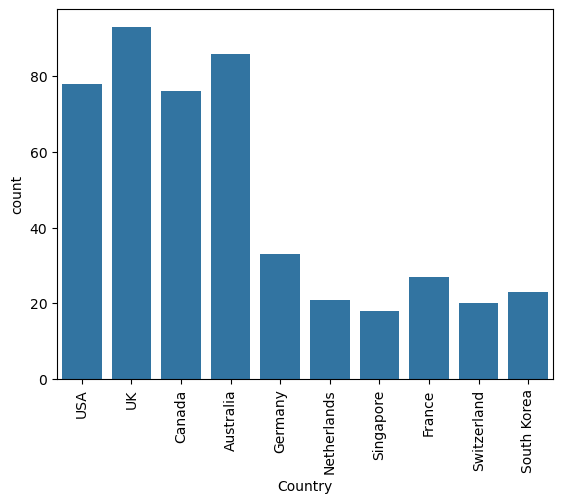

In [75]:
sns.countplot(data = country,x = 'Country')
plt.xticks(rotation = 'vertical')
plt.show

In [77]:
df['City'].value_counts().head()

City
Singapore    18
Melbourne    11
Sydney       11
London       10
Canberra      8
Name: count, dtype: int64

In [78]:
city = df[df['City'].isin(['Singapore','Melbourne','Sydney','London','Canberra'])]

In [79]:
city

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
1,UK,London,Imperial College London,Data Science,Master,1.0,41200,75.800003,1800,485,800,0
3,Australia,Melbourne,University of Melbourne,Engineering,Master,2.0,42000,71.199997,1400,450,650,1
7,Singapore,Singapore,National University of Singapore,Finance,Master,1.5,35000,81.099998,1900,90,800,1
36,Singapore,Singapore,NTU Singapore,Data Science,PhD,4.0,8900,81.500000,1600,90,800,1
38,Australia,Canberra,Australian National University,Climate Science,PhD,4.0,29800,70.199997,1400,450,650,1
53,Australia,Sydney,University of Sydney,Business,Bachelor,3.0,35000,72.800003,1600,450,650,1
101,UK,London,University College London,Computer Science,Master,1.0,39200,76.199997,1900,485,800,0
151,Singapore,Singapore,Nanyang Technological University,Computer Science,Bachelor,4.0,32500,81.099998,1500,90,800,1
152,Singapore,Singapore,Singapore Management University,Information Systems,Bachelor,4.0,31800,81.099998,1500,90,800,1
153,Singapore,Singapore,SUTD,Computer Science & Design,Bachelor,4.0,31200,81.099998,1500,90,800,1


<Axes: xlabel='Level', ylabel='count'>

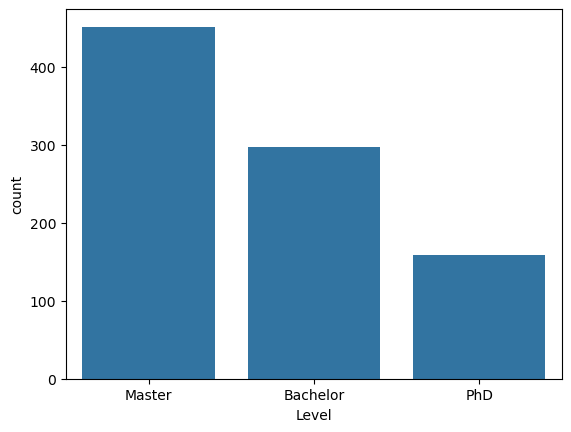

In [80]:
sns.countplot(data = df , x = 'Level')

In [81]:
df.columns

Index(['Country', 'City', 'University', 'Program', 'Level', 'Duration_Years',
       'Tuition_USD', 'Living_Cost_Index', 'Rent_USD', 'Visa_Fee_USD',
       'Insurance_USD', 'Exchange_Rate'],
      dtype='object')

<Axes: xlabel='Tuition_USD', ylabel='Count'>

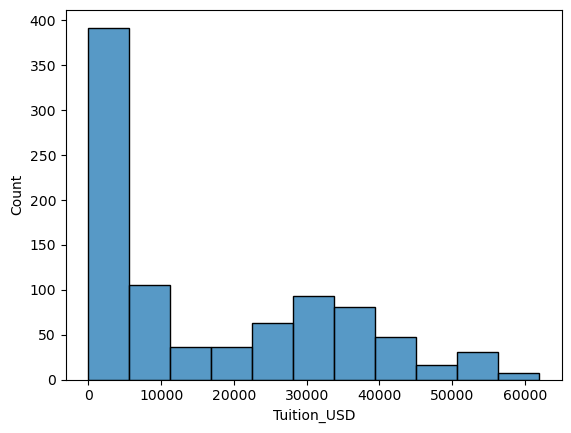

In [83]:
sns.histplot(data = df , x = 'Tuition_USD')

sns.histplot(data = df , x = 'Rent_USD' , kde = True)

# bivariate analysis

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'USA'),
  Text(1, 0, 'UK'),
  Text(2, 0, 'Canada'),
  Text(3, 0, 'Australia'),
  Text(4, 0, 'Germany'),
  Text(5, 0, 'Netherlands'),
  Text(6, 0, 'Singapore'),
  Text(7, 0, 'France'),
  Text(8, 0, 'Switzerland'),
  Text(9, 0, 'South Korea')])

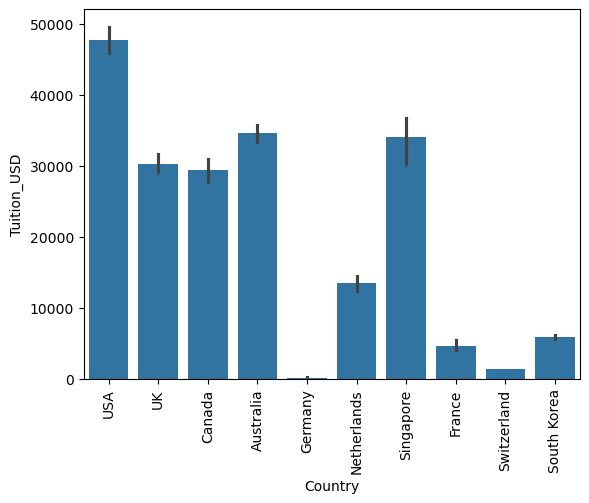

In [96]:
sns.barplot(data = country, x='Country',y = 'Tuition_USD')
plt.xticks(rotation = 90)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'USA'),
  Text(1, 0, 'UK'),
  Text(2, 0, 'Canada'),
  Text(3, 0, 'Australia'),
  Text(4, 0, 'Germany'),
  Text(5, 0, 'Netherlands'),
  Text(6, 0, 'Singapore'),
  Text(7, 0, 'France'),
  Text(8, 0, 'Switzerland'),
  Text(9, 0, 'South Korea')])

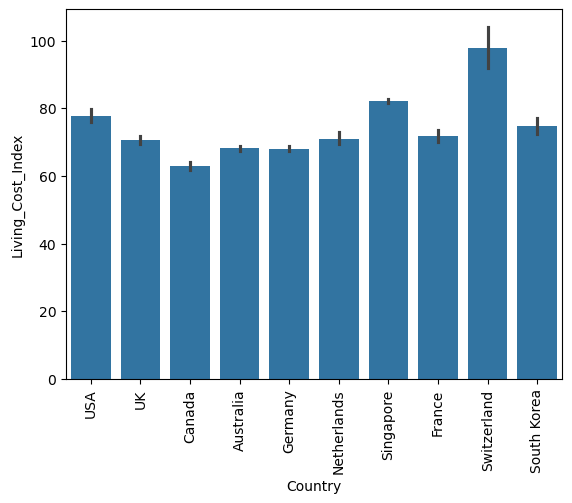

In [97]:
sns.barplot(data = country, x='Country',y = 'Living_Cost_Index')
plt.xticks(rotation = 90)

<Axes: xlabel='Country', ylabel='Living_Cost_Index'>

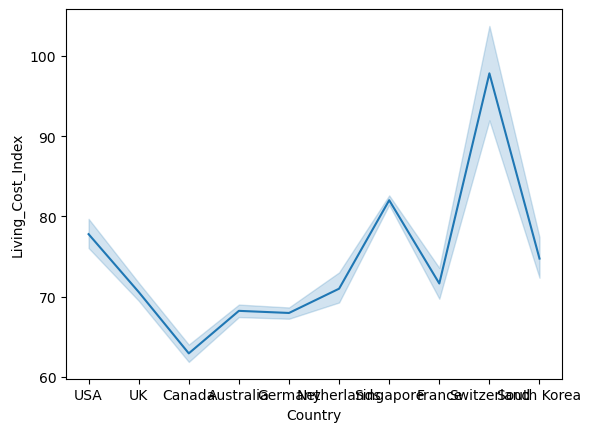

In [98]:
sns.lineplot(data = country, x='Country',y = 'Living_Cost_Index')


<Axes: xlabel='Country', ylabel='Tuition_USD'>

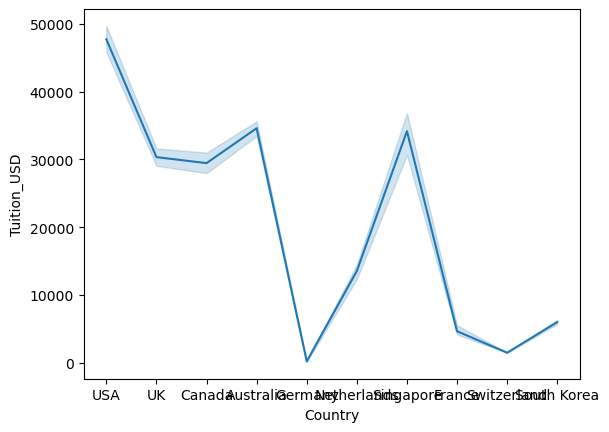

In [99]:
sns.lineplot(data = country, x='Country',y = 'Tuition_USD')

<Axes: xlabel='Country', ylabel='Exchange_Rate'>

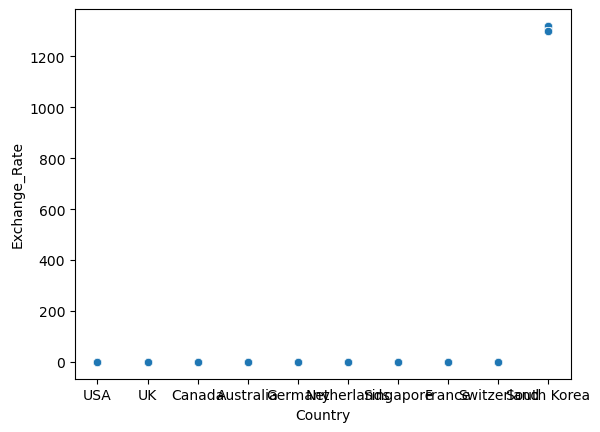

In [101]:
sns.scatterplot(data = country, x='Country',y = 'Exchange_Rate')

In [102]:
country['Country'].value_counts()

Country
UK             93
Australia      86
USA            78
Canada         76
Germany        33
France         27
South Korea    23
Netherlands    21
Switzerland    20
Singapore      18
Name: count, dtype: int64

In [105]:
sns.heatmap(df['Tuition_USD'])
plt.show()

IndexError: Inconsistent shape between the condition and the input (got (907, 1) and (907,))

Feature engineering  

In [106]:
df.head()

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
0,USA,Cambridge,Harvard University,Computer Science,Master,2.0,55400,83.500000,2200,160,1500,1
1,UK,London,Imperial College London,Data Science,Master,1.0,41200,75.800003,1800,485,800,0
2,Canada,Toronto,University of Toronto,Business Analytics,Master,2.0,38500,72.500000,1600,235,900,1
3,Australia,Melbourne,University of Melbourne,Engineering,Master,2.0,42000,71.199997,1400,450,650,1
4,Germany,Munich,Technical University of Munich,Mechanical Engineering,Master,2.0,500,70.500000,1100,75,550,0


In [109]:
df = df[['Country','City','University','Program','Level','Duration_Years','Living_Cost_Index','Visa_Fee_USD','Insurance_USD']]

In [111]:
df.head()

,Country,City,University,Program,Level,Duration_Years,Living_Cost_Index,Visa_Fee_USD,Insurance_USD
0,USA,Cambridge,Harvard University,Computer Science,Master,2.0,83.500000,160,1500
1,UK,London,Imperial College London,Data Science,Master,1.0,75.800003,485,800
2,Canada,Toronto,University of Toronto,Business Analytics,Master,2.0,72.500000,235,900
3,Australia,Melbourne,University of Melbourne,Engineering,Master,2.0,71.199997,450,650
4,Germany,Munich,Technical University of Munich,Mechanical Engineering,Master,2.0,70.500000,75,550


Label encoding (categorial data -> numerical data)

In [112]:
from sklearn.preprocessing import LabelEncoder

In [113]:
le = LabelEncoder()

In [121]:
df.loc[:, 'Country'] = le.fit_transform(df['Country'])

In [122]:
df['Country']

0      66
1      65
2       9
3       2
4      22
       ..
902    21
903    38
904    51
905    66
906    65
Name: Country, Length: 907, dtype: int64

In [123]:
df.head()

,Country,City,University,Program,Level,Duration_Years,Living_Cost_Index,Visa_Fee_USD,Insurance_USD,country
0,66,Cambridge,Harvard University,Computer Science,Master,2.0,83.500000,160,1500,66
1,65,London,Imperial College London,Data Science,Master,1.0,75.800003,485,800,65
2,9,Toronto,University of Toronto,Business Analytics,Master,2.0,72.500000,235,900,9
3,2,Melbourne,University of Melbourne,Engineering,Master,2.0,71.199997,450,650,2
4,22,Munich,Technical University of Munich,Mechanical Engineering,Master,2.0,70.500000,75,550,22


In [124]:
df.loc[:, 'City'] = le.fit_transform(df['City'])

In [125]:
df.loc[:, 'University'] = le.fit_transform(df['University'])

In [126]:
df.loc[:, 'Program'] = le.fit_transform(df['Program'])

In [127]:
df.loc[:, 'Level'] = le.fit_transform(df['Level'])

In [128]:
df.head()

,Country,City,University,Program,Level,Duration_Years,Living_Cost_Index,Visa_Fee_USD,Insurance_USD,country
0,66,84,101,17,1,2.0,83.500000,160,1500,66
1,65,283,128,27,1,1.0,75.800003,485,800,65
2,9,503,572,9,1,2.0,72.500000,235,900,9
3,2,313,495,44,1,2.0,71.199997,450,650,2
4,22,330,307,66,1,2.0,70.500000,75,550,22


# Saperate Input and Output Data

In [132]:
x = df.iloc[:,:9]

In [3]:
from sklearn.preprocessing import StandardScaler
s = StandardScaler()

In [5]:
from sklearn.model_selection import train_test_split